# HKEX parser sanity check

In [67]:
from pathlib import Path
from datetime import datetime

import pandas as pd
import pyarrow.parquet as pq
import pyarrow.compute as pc

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [18]:
data_path = Path("../../data/market_data/product=HSI/year=2026/month=02")
print(f"Existing data file: {data_path.exists()}")

Existing data file: True


## Opening HSI trades or orders files

In [19]:
orders_path = data_path / 'HSI_20260202_orders.parquet'
trades_path = data_path / 'HSI_20260202_trades.parquet'

# Ouvrir le fichier sans rien charger en RAM
orders = pq.ParquetFile(orders_path)
trades = pq.ParquetFile(trades_path)

## Checking orders on date 2026-02-02

In [65]:
print(f"Row groups : {orders.metadata.num_row_groups}")
print(f"Total rows : {orders.metadata.num_rows:,}")
print(f"Schema     : {orders.schema_arrow}")

Row groups : 118
Total rows : 58,784,388
Schema     : timestamp_ns: int64
event_type: string
orderbook_id: int64
order_id: int64
class_code: string
side: string
price: int32
quantity: int32


In [23]:
matched   = 0
orphan    = 0
add_ids   = set()

# Passe 1 : collecter tous les order_id des Add
for batch in orders.iter_batches(columns=['event_type', 'order_id']):
    mask = pc.equal(batch.column('event_type'), 'A')
    ids  = pc.filter(batch.column('order_id'), mask)
    add_ids.update(ids.to_pylist())

# Passe 2 : vérifier les Delete
for batch in orders.iter_batches(columns=['event_type', 'order_id']):
    mask    = pc.equal(batch.column('event_type'), 'D')
    del_ids = pc.filter(batch.column('order_id'), mask).to_pylist()
    for oid in del_ids:
        if oid in add_ids:
            matched += 1
        else:
            orphan  += 1

print(f"Deletes matchés  : {matched:,}  ({matched/(matched+orphan):.1%})")
print(f"Deletes orphelins: {orphan:,}")

Deletes matchés  : 29,319,977  (100.0%)
Deletes orphelins: 0


## Checking trades on 2026-02-02

In [29]:
print(f"Row groups : {trades.metadata.num_row_groups}")
print(f"Total rows : {trades.metadata.num_rows:,}")
print(f"Schema     : {trades.schema_arrow}")

Row groups : 1
Total rows : 155,232
Schema     : timestamp_ns: int64
trade_time_ns: int64
orderbook_id: int64
trade_id: int64
class_code: string
side: string
price: int32
quantity: int64
is_printable: bool


In [55]:
count_A = total = 0

for batch in trades.iter_batches(columns=['side']):
    col = batch.column('side')
    count_A += pc.sum(pc.equal(col, 'A')).as_py()
    total += len(col)

print(f"Side Ask rate : {count_A/total:.2%}")

Side Ask rate : 50.13%


In [58]:
count_is_printable = total = 0

for batch in trades.iter_batches(columns=['is_printable']):
    col = batch.column('is_printable')
    count_is_printable += pc.sum(col).as_py()
    total += len(col)

print(f"is_printable rate : {count_is_printable/total:.2%}")

is_printable rate : 99.45%


In [76]:
threshold = 26000
price_below = price_above = total = 0

for batch in trades.iter_batches(columns=['price']):
    col = batch.column('price')
    total = len(col)
    price_below = pc.sum(pc.less(col, 26000)).as_py()
    price_above = total - price_below

print(f"Prices above {threshold:,} : {price_above/total:.2%}")
print(f"Prices below {threshold:,} : {price_below/total:.2%}")

Prices above 26,000 : 87.84%
Prices below 26,000 : 12.16%


### More statistics

In [46]:
df = pd.read_parquet(trades_path, engine="pyarrow")

In [47]:
# Adding a more readable datetime column
df["timestamp"] = pd.to_datetime(df["timestamp_ns"], unit="ns", utc=True).dt.tz_convert("Asia/Hong_Kong").dt.tz_localize(None)
df = df[['timestamp'] + [c for c in df.columns if c != 'timestamp']]

In [48]:
df.shape

(155232, 10)

In [49]:
df.head(10)

,timestamp,timestamp_ns,trade_time_ns,orderbook_id,trade_id,class_code,side,price,quantity,is_printable
0,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,B,27210,1,False
1,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,A,27210,3,True
2,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,B,27210,1,False
3,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,B,27210,1,False
4,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,B,27210,1,False
5,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,A,27210,3,True
6,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,B,27210,1,False
7,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,B,27210,1,False
8,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,B,27210,5,False
9,2026-02-02 09:14:00.024,1769994840024000000,1769994840010000000,135335842,8108676166384091320,HSI,A,27210,1,True


### Graphics

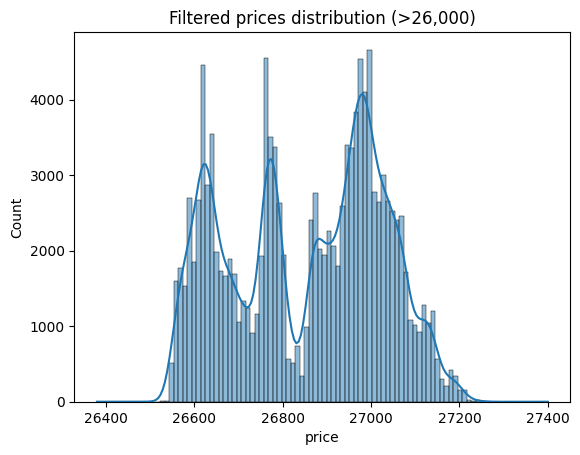

In [80]:
sns.histplot(df.price[df.price > 26000], bins=100, kde=True)
plt.title("Filtered prices distribution (>26,000)")
plt.show()

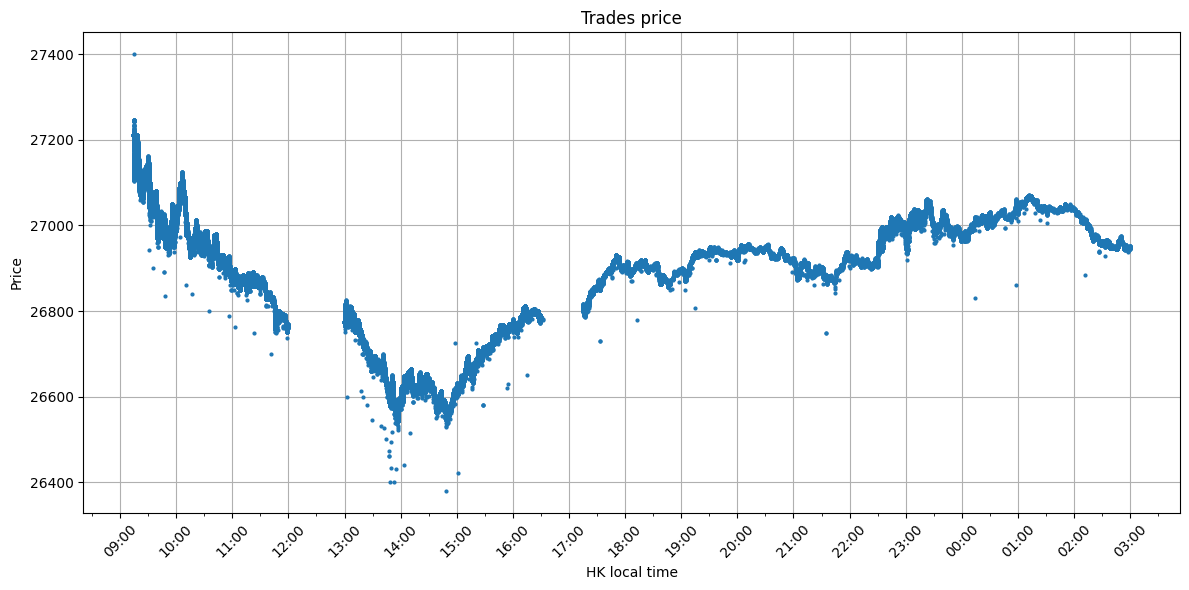

In [89]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df[df.price > 26000]["timestamp"], df[df.price > 26000]["price"], marker='o', linestyle='', markersize=2)
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator())                  # tick at every hour
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0,30])) # tick at 0 and 30
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))       # Formatter

plt.xlabel("HK local time")
plt.ylabel("Price")
plt.title("Trades price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()